In [21]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img,img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [3]:
data=tf.keras.preprocessing.image_dataset_from_directory('/content/drive/MyDrive/Colab Notebooks/maskdetection',
                                                         shuffle=True,
                                                         image_size=(224,224),
                                                         batch_size=32)

Found 4569 files belonging to 3 classes.


In [4]:
classes=data.class_names
classes

['Correct', 'Incorrect', 'NoMask']

In [5]:
train_datagen=ImageDataGenerator(rescale=1./255,shear_range=0.1,
                                 zoom_range=0.2,horizontal_flip=True,
                                 validation_split=0.2)
training_set=train_datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/maskdetection',
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='categorical',
                                               subset='training')

Found 3656 images belonging to 3 classes.


In [6]:
validation_datagen=ImageDataGenerator(rescale=1./255,shear_range=0.1,
                                      zoom_range=0.2,horizontal_flip=True,
                                      validation_split=0.2)
validation_set=validation_datagen.flow_from_directory('/content/drive/MyDrive/Colab Notebooks/maskdetection',
                                                     target_size=(224,224),
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     subset='validation')

Found 913 images belonging to 3 classes.


In [26]:
model = Sequential()

# First Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Fourth Convolutional Block
model.add(Conv2D(128, (3, 3), activation='relu'))

# Instead of applying pooling here, we use GlobalAveragePooling2D to keep feature map dimensions intact
model.add(GlobalAveragePooling2D())

# Fully Connected Layers
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(3, activation='softmax'))

In [27]:
model.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [28]:
training_data=model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 85s 695ms/step - accuracy: 0.4474 - loss: 2.0037 - val_accuracy: 0.7744 - val_loss: 0.7862
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 77s 671ms/step - accuracy: 0.8142 - loss: 0.6751 - val_accuracy: 0.7689 - val_loss: 0.7318
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 75s 653ms/step - accuracy: 0.8598 - loss: 0.5252 - val_accuracy: 0.7875 - val_loss: 0.6866
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 78s 684ms/step - accuracy: 0.8769 - loss: 0.4485 - val_accuracy: 0.7886 - val_loss: 0.6990
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 75s 653ms/step - accuracy: 0.8531 - loss: 0.4841 - val_accuracy: 0.8226 - val_loss: 0.6084
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 75s 653ms/step - accuracy: 0.8778 - loss: 0.4263 - val_accuracy: 0.8061 - val_loss: 0.6435
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 84s 670ms/step - accuracy: 0.8828 - loss: 0.3764 - val_accuracy: 0.8291 - val_loss: 0.5423
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 667ms/step - accuracy: 0.8855 - loss: 0

In [30]:
hist=training_data.history
hist.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [31]:
hist['val_accuracy'][-1]

0.8017524480819702

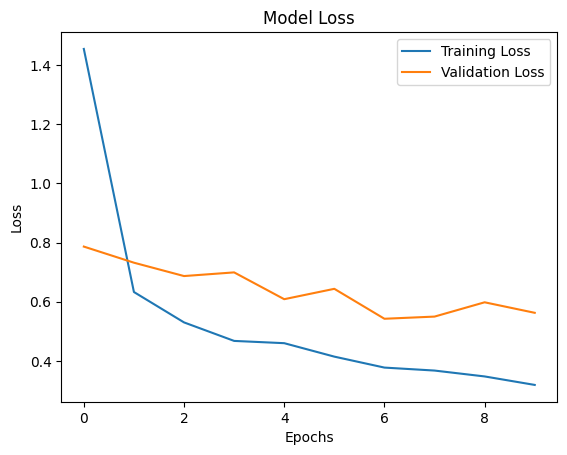

In [32]:
plt.plot(hist['loss'],label='Training Loss')
plt.plot(hist['val_loss'],label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

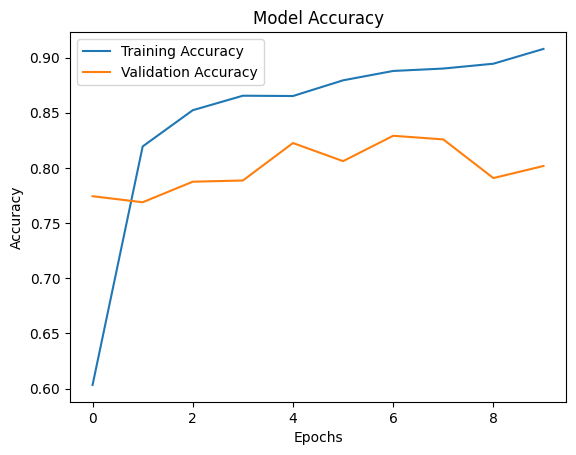

In [33]:
plt.plot(hist['accuracy'],label='Training Accuracy')
plt.plot(hist['val_accuracy'],label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()
#

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: Correct


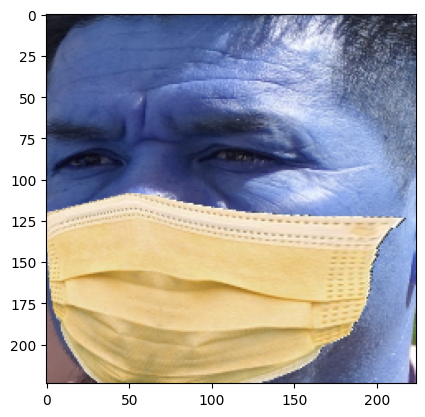

In [34]:
test_image=load_img('/content/drive/MyDrive/Colab Notebooks/maskdetection/Correct/0.jpg',target_size=(224,224))
plt.imshow(cv2.imread('/content/drive/MyDrive/Colab Notebooks/maskdetection/Correct/0.jpg'))
test_img_array=img_to_array(test_image)
test_img_array=np.expand_dims(test_img_array,axis=0)
test_img_array.shape
result=model.predict(test_img_array)
predict_classes=np.argmax(result)
predict_classes_name=classes[predict_classes]
print('Predicted Class:',predict_classes_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Class: Incorrect


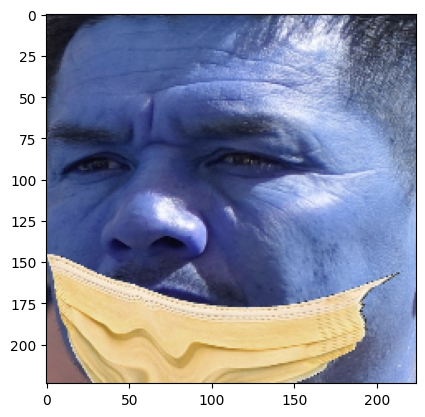

In [35]:
test_image=load_img('/content/drive/MyDrive/Colab Notebooks/maskdetection/Incorrect/0.jpg',target_size=(224,224))
plt.imshow(cv2.imread('/content/drive/MyDrive/Colab Notebooks/maskdetection/Incorrect/0.jpg'))
test_img_array=img_to_array(test_image)
test_img_array=np.expand_dims(test_img_array,axis=0)
test_img_array.shape
result=model.predict(test_img_array)
predict_classes=np.argmax(result)
predict_classes_name=classes[predict_classes]
print('Predicted Class:',predict_classes_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Predicted Class: NoMask


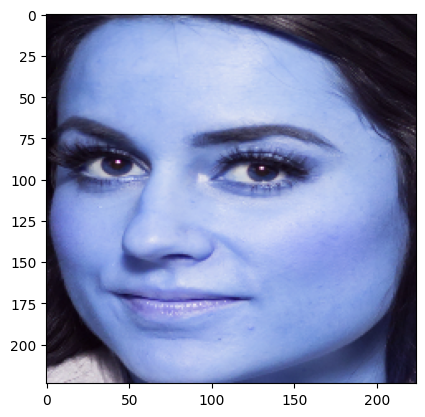

In [37]:
test_image=load_img('/content/drive/MyDrive/Colab Notebooks/maskdetection/NoMask/10.png',target_size=(224,224))
plt.imshow(cv2.imread('/content/drive/MyDrive/Colab Notebooks/maskdetection/NoMask/10.png'))
test_img_array=img_to_array(test_image)
test_img_array=np.expand_dims(test_img_array,axis=0)
test_img_array.shape
result=model.predict(test_img_array)
predict_classes=np.argmax(result)
predict_classes_name=classes[predict_classes]
print('Predicted Class:',predict_classes_name)